<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/12_robust_student_t_and_loo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 12 — Robust likelihoods and PSIS-LOO

Notebooks 4 and 5 described each participant's reaction times as Gaussian scatter around their own trajectory. A Gaussian makes large deviations from the trajectory very improbable, so a few unusual observations can pull the fit toward themselves. A **Student-t** likelihood has heavier tails: it expects most observations to lie close to the trajectory and allows an occasional one to lie far from it.

This notebook compares four models: Notebook 4's varying-intercept model and Notebook 5's varying-intercept, varying-slope model, each with a Gaussian and with a Student-t likelihood. It asks two questions: does a Student-t likelihood predict the data better, and do varying slopes? Each change is judged both with and without the other. The comparison uses **leave-one-out cross-validation**, which is new in this course: each observation is predicted by the model fitted without it.

All four models are fitted here from scratch, so this notebook does not depend on anything computed in the earlier notebooks.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

participants = sorted(sleep["Subject"].unique(), key=int)
participant_to_idx = {participant: i for i, participant in enumerate(participants)}
participant_idx = sleep["Subject"].map(participant_to_idx).to_numpy()

assert participant_idx.min() == 0
assert participant_idx.max() == len(participants) - 1
assert np.array_equal(
    np.asarray(participants)[participant_idx],
    sleep["Subject"].to_numpy(),
)

print(f"{len(participants)} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


### Plotting helper

The plotting helper `plot_loo_participants` is supplied; Question 2.3 explains what it plots. Like the participant plots of the previous notebooks, it draws one panel per participant, with the day of sleep deprivation on the horizontal axis and that participant's observations in black. Each panel is titled with its participant.

In [4]:
PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(
        sleep[["Subject", "Days"]],
        names=["participant", "day"],
    ),
    "obs_id",
)

def plot_loo_participants(dt):
    """One panel per participant: leave-one-out predictive intervals with that participant's data."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")

    panels = xr.DataTree.from_dict({
        "posterior": dt["posterior"].to_dataset(),
        "posterior_predictive": reshape(dt["posterior_predictive"].to_dataset()),
        "log_likelihood": reshape(dt["log_likelihood"].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
    })

    pc = azp.plot_loo_interval(
        panels,
        var_names=["y"],
        point_estimate="mean",
        ci_probs=(0.50, 0.90),
        cols=["participant"],
        col_wrap=6,
        labeller=azb.labels.NoVarLabeller(),
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={
            "prediction_markers": {"color": "C1", "marker": "_", "size": 80, "width": 2},
            "observed_markers": {"color": "black", "size": 14},
            "title": True,
            "xlabel": False,
            "ylabel": False,
        },
    )

    fig = pc.get_viz("figure")
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")
    return pc

## 1. Four models to compare

### 1.1 The four models

In all four models, the reaction time $y_i$ varies around an expected trajectory $\mu_{y,i}$ that belongs to the participant $s[i]$ who produced observation $i$, and participant intercepts are drawn from a population, as in Notebooks 4 and 5:

$$
b_{0,s}
\sim
\operatorname{Normal}(\mu_{b0}, sd_{b0}).
$$

The models differ in two respects, which are varied independently. The **mean structure** either gives all participants one shared slope, or lets each participant have their own:

$$
\mu_{y,i}
=
b_{0,s[i]}
+
b_1\,\mathrm{days}_i
\qquad\text{or}\qquad
\mu_{y,i}
=
b_{0,s[i]}
+
b_{1,s[i]}\,\mathrm{days}_i,
\quad
b_{1,s}
\sim
\operatorname{Normal}(\mu_{b1}, sd_{b1}).
$$

The **likelihood** is either Gaussian or Student-t:

$$
y_i
\sim
\operatorname{Normal}(\mu_{y,i}, sd_y)
\qquad\text{or}\qquad
y_i
\sim
\operatorname{StudentT}(\nu, \mu_{y,i}, sd_y).
$$

| Model | Mean structure | Likelihood |
|---|---|---|
| `gaussian_intercept` | shared slope | Gaussian: Notebook 4's model |
| `gaussian_slope` | varying slopes | Gaussian: Notebook 5's model |
| `student_t_intercept` | shared slope | Student-t |
| `student_t_slope` | varying slopes | Student-t |

As in Notebook 4, the shared slope is `b1`, a single value for all participants. As in Notebook 5, the varying slopes are `b1` with one value per participant, and their population average is `mu_b1`. Every prior except the one for $\nu$ is carried over unchanged from Notebooks 4 and 5.

### 1.2 What does $\nu$ control?

$\nu$ is the Student-t's **degrees of freedom**. Notebook 3 used a Student-t with $\nu = 7$ as a heavy-tailed prior for the slope; here the Student-t describes the observations, and $\nu$ is estimated from the data. How does the Student-t distribution change as $\nu$ grows large, and what does a small $\nu$, such as 2 or 3, say about deviations from the trajectory?

It controls how heavy the tails are. As $\nu$ grows, the Student-t approaches a Gaussian with standard deviation $sd_y$; above about 30, the two are hard to tell apart. A small $\nu$ gives heavy tails: most observations still lie close to the trajectory, but deviations of several times $sd_y$ are far more probable than under a Gaussian. For $\nu \le 2$, the distribution does not even have a finite standard deviation, so in the Student-t models $sd_y$ is a scale rather than a standard deviation.

Because the Gaussian is the limiting case, the Student-t models can learn from the data how heavy the tails need to be.

### 1.3 Where does the prior for $\nu$ come from, and what does it say?

We use $\nu \sim \operatorname{Gamma}(2, 0.1)$, with shape 2 and rate 0.1. It is the default prior for $\nu$ in the Student-t family of Bambi, the formula interface to PyMC used in the bioassay notebook (checked in Bambi 0.21.0). A default is still a prior choice, so it is worth knowing where it comes from and what it says.

Its mean is 20. It gives about 9% probability to $\nu < 5$, heavy tails, and about 20% to $\nu > 30$, practically Gaussian tails, so it lets the data choose between them. It makes values below 2, with no finite standard deviation, improbable: about 2%.

The other priors were checked in Notebooks 4 and 5. This notebook is about checking predictions after fitting, so it makes no new prior predictive check.

### 1.4 The supplied model-building function

One function builds all four models, with the likelihood and the mean structure as its two arguments. The prior constants are Notebook 5's; Notebook 4 used the same values for its intercepts, its shared slope, and `sd_y`. As in Notebooks 4 and 5, `b0` and `b1` are written in the centered form: each participant's value is drawn directly from the population distribution.

In [5]:
coords = {
    "obs_id": np.arange(len(sleep)),
    "participant": participants,
}

# Hyperprior constants for the intercept hierarchy (Notebooks 4 and 5)
mu_mu_b0 = 250   # ms
sd_mu_b0 = 100   # ms
sd_sd_b0 = 25    # ms

# Hyperprior constants for the slope (Notebook 5; Notebook 4's shared slope used the first two)
mu_mu_b1 = 0     # ms/day
sd_mu_b1 = 20    # ms/day
sd_sd_b1 = 10    # ms/day

# Prior constant for observation-level variation (Notebooks 4 and 5)
mu_sd_y = 50     # ms

# Prior constants for the Student-t degrees of freedom (Bambi's default)
alpha_nu = 2
beta_nu = 0.1


def build_model(likelihood, varying_slope):
    """Gaussian or Student-t likelihood, with a shared slope or varying slopes."""
    with pm.Model(coords=coords) as model:
        days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")
        pidx = pm.Data("participant_idx", participant_idx, dims="obs_id")

        # Varying intercepts
        mu_b0 = pm.Normal("mu_b0", mu=mu_mu_b0, sigma=sd_mu_b0)
        sd_b0 = pm.Exponential("sd_b0", scale=sd_sd_b0)
        b0 = pm.Normal("b0", mu=mu_b0, sigma=sd_b0, dims="participant")

        if varying_slope:
            # Varying slopes (Notebook 5)
            mu_b1 = pm.Normal("mu_b1", mu=mu_mu_b1, sigma=sd_mu_b1)
            sd_b1 = pm.Exponential("sd_b1", scale=sd_sd_b1)
            b1 = pm.Normal("b1", mu=mu_b1, sigma=sd_b1, dims="participant")
            mu_y = pm.Deterministic("mu_y", b0[pidx] + b1[pidx] * days, dims="obs_id")
        else:
            # One slope shared by all participants (Notebook 4), with the prior of mu_b1
            b1 = pm.Normal("b1", mu=mu_mu_b1, sigma=sd_mu_b1)
            mu_y = pm.Deterministic("mu_y", b0[pidx] + b1 * days, dims="obs_id")

        # Likelihood
        sd_y = pm.Exponential("sd_y", scale=mu_sd_y)
        if likelihood == "gaussian":
            y = pm.Normal(
                "y",
                mu=mu_y,
                sigma=sd_y,
                observed=sleep["Reaction"].to_numpy(),
                dims="obs_id",
            )
        else:
            nu = pm.Gamma("nu", alpha=alpha_nu, beta=beta_nu)
            y = pm.StudentT(
                "y",
                nu=nu,
                mu=mu_y,
                sigma=sd_y,
                observed=sleep["Reaction"].to_numpy(),
                dims="obs_id",
            )
    return model


models = {
    "gaussian_intercept": build_model("gaussian", varying_slope=False),
    "gaussian_slope": build_model("gaussian", varying_slope=True),
    "student_t_intercept": build_model("student_t", varying_slope=False),
    "student_t_slope": build_model("student_t", varying_slope=True),
}

### 1.5 How is a shared-slope model related to the varying-slope model with the same likelihood?

In the shared-slope models, one `b1` applies to every participant. Which parameter of the varying-slope model would have to be zero to give the same mean structure, and which varying-slope parameter would the shared `b1` then correspond to?

`sd_b1`, the between-participant standard deviation of the slopes. If it were zero, every participant's `b1` would equal `mu_b1`, so the shared slope `b1` corresponds to `mu_b1`, the population-average slope. A shared-slope model is therefore the limiting case of the varying-slope model in which participants do not differ in their response to sleep deprivation; the varying-slope model lets the data decide how much they differ.

### 1.6 Fit the four models.

Each model is sampled with the settings of Notebooks 4 and 5. Sampling all four takes about a minute.

In [6]:
idatas = {}
for name, model in models.items():
    with model:
        idatas[name] = pm.sample(
            draws=1000,
            tune=1500,
            chains=4,
            random_seed=RANDOM_SEED,
        )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [mu_b0, sd_b0, b0, b1, sd_y]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 5 seconds.


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [mu_b0, sd_b0, b0, mu_b1, sd_b1, b1, sd_y, nu]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 7 seconds.


### 1.7 Check the diagnostics of all four fits.

The table screens every parameter of each model, including each participant's intercept and slope: it reports the number of divergences and the worst R-hat and ESS values. The summaries below it show each model's population-level parameters: those with a single value per draw, rather than one per participant or observation.

In [7]:
screen = {}
for name, idata in idatas.items():
    diagnostics = azs.summary(idata, var_names=["~mu_y"], kind="diagnostics", round_to=2)
    screen[name] = {
        "divergences": int(idata["sample_stats"]["diverging"].sum().item()),
        "largest R-hat": diagnostics["r_hat"].max(),
        "smallest bulk ESS": diagnostics["ess_bulk"].min(),
        "smallest tail ESS": diagnostics["ess_tail"].min(),
    }
display(pd.DataFrame.from_dict(screen, orient="index"))

for name, idata in idatas.items():
    posterior = idata["posterior"]
    population = [var for var in posterior.data_vars if set(posterior[var].dims) == {"chain", "draw"}]
    print(name)
    display(azs.summary(
        idata,
        var_names=population,
        ci_prob=0.90,
        ci_kind="hdi",
        round_to=2,
    ))

,divergences,largest R-hat,smallest bulk ESS,smallest tail ESS
gaussian_intercept,0,1.00,1951.50,2612.17
gaussian_slope,0,1.00,3436.06,2677.03
student_t_intercept,0,1.00,1505.37,2255.54
student_t_slope,0,1.01,2004.54,2097.73


gaussian_intercept


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_b0,267.89,10.92,250.11,285.51,4039.39,3077.36,1.0,0.17,0.18
b1,11.42,1.12,9.55,13.22,1951.50,2612.17,1.0,0.03,0.02
sd_b0,42.43,7.92,29.83,53.90,6771.25,3219.69,1.0,0.10,0.15
sd_y,30.48,1.90,27.32,33.40,6021.48,3462.85,1.0,0.02,0.03


gaussian_slope


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_b0,268.02,8.78,254.05,282.70,5210.23,3480.07,1.0,0.12,0.15
mu_b1,11.29,1.99,8.10,14.55,4724.63,3059.15,1.0,0.03,0.04
sd_b0,32.49,6.94,21.12,42.97,4190.70,3334.30,1.0,0.11,0.12
sd_b1,7.34,1.67,4.73,9.98,3436.06,3304.26,1.0,0.03,0.03
sd_y,25.71,1.78,22.86,28.64,4491.91,3179.39,1.0,0.03,0.03


student_t_intercept


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_b0,268.80,11.12,251.24,288.03,3450.69,2892.22,1.0,0.19,0.17
b1,11.55,1.02,9.83,13.11,1505.37,2255.54,1.0,0.03,0.01
sd_b0,44.14,7.83,31.81,56.50,5185.48,3364.03,1.0,0.11,0.13
sd_y,22.86,2.74,18.39,27.43,2495.45,2614.34,1.0,0.06,0.04
nu,6.30,4.17,2.00,10.25,2781.59,2535.21,1.0,0.09,0.23


student_t_slope


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_b0,268.01,8.83,253.42,282.37,5561.77,2904.29,1.0,0.12,0.19
mu_b1,11.55,2.00,8.24,14.69,5102.65,2859.93,1.0,0.03,0.04
sd_b0,35.35,6.82,24.08,45.11,4786.34,2769.65,1.0,0.11,0.14
sd_b1,7.91,1.61,5.34,10.36,4172.94,3220.44,1.0,0.03,0.03
sd_y,12.17,1.78,9.25,15.02,2004.54,2283.75,1.0,0.04,0.03
nu,2.62,0.78,1.51,3.73,2848.43,2929.64,1.0,0.01,0.02


### 1.8 Plot the traces of the population-level parameters of `student_t_slope`.

It is the only model with all six population-level parameters, including `nu`. Use `azp.plot_trace_dist`.

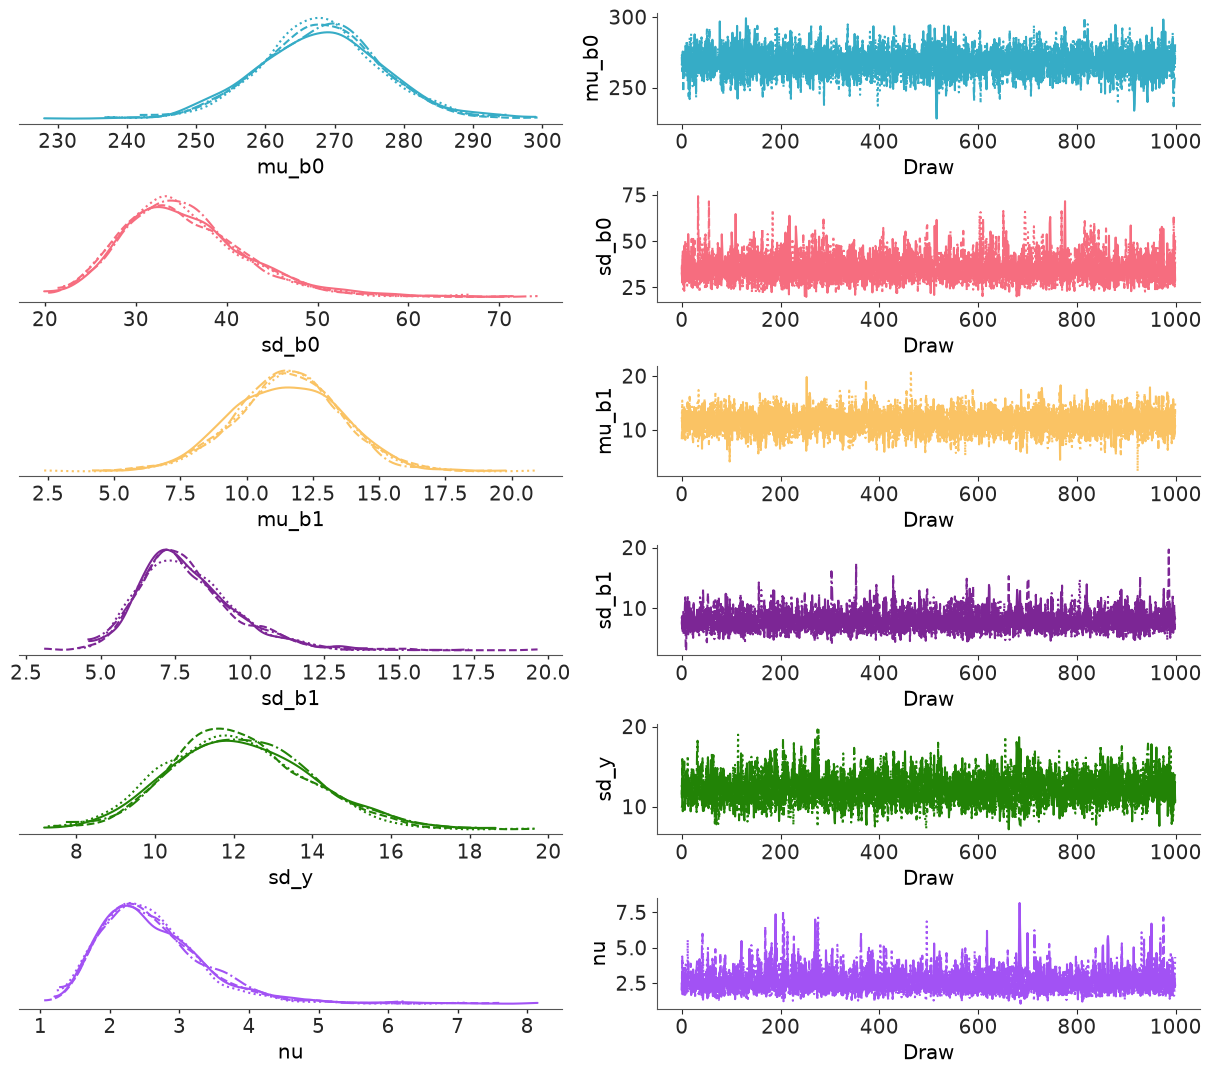

In [8]:
azp.plot_trace_dist(
    idatas["student_t_slope"],
    var_names=["mu_b0", "sd_b0", "mu_b1", "sd_b1", "sd_y", "nu"],
);

### 1.9 Do all four fits meet the diagnostic criteria?

Use the criteria established in Notebook 1: no divergences, R-hat close to 1, adequate bulk and tail ESS, and well-mixed traces.

Yes. None of the four fits has a divergence. Across every parameter of every model, including the participant-level ones, the largest R-hat is 1.01, and every bulk and tail ESS is about 1,500 or more. The traces of `student_t_slope` show well-mixed chains, including that of `nu`. As in Notebooks 4 and 5, the centered parameterization samples all four models reliably with PyMC's default settings.

## 2. Difficult-to-predict observations

### 2.1 How well does a model predict an observation it has not seen?

A posterior predictive check compares each observation with predictions from a posterior that was fitted to that same observation, so it flatters the model: an unusual observation pulls the fit toward itself and then looks less unusual. **Leave-one-out (LOO) cross-validation** asks a fairer question: fit the model without observation $i$, and ask how well it predicts $y_i$. Doing this exactly would mean refitting each model 144 times.

**PSIS-LOO** approximates all 144 leave-one-out fits from the one fit we already have. Leaving out one of 144 observations usually changes the posterior only slightly, so the draws of the full posterior can be reweighted to stand in for draws from the posterior without observation $i$: draws under which $y_i$ is probable get less weight, because $y_i$ itself pulled the full posterior toward them. This reweighting is called importance sampling, and **Pareto smoothing**, the PS in PSIS, stabilizes the largest weights. When leaving out an observation would change the posterior a lot, the approximation becomes unreliable, and ArviZ warns about it. Section 4 shows how to read that diagnostic.

### 2.2 What does PSIS-LOO need?

It needs the **pointwise log likelihood**, $\log p(y_i \mid \theta)$ for every observation $i$ and every posterior draw $\theta$, which gives the weights, and posterior predictive draws of $y$, which are reweighted into leave-one-out predictions. PyMC does not store the pointwise log likelihood by default. The next cell adds both to each model's `idata`.

In [9]:
for name, model in models.items():
    with model:
        pm.compute_log_likelihood(idatas[name])
        pm.sample_posterior_predictive(
            idatas[name],
            var_names=["y"],
            extend_inferencedata=True,
            random_seed=RANDOM_SEED,
        )

Output()

Sampling: [y]


Output()

Output()

Sampling: [y]


...

Sampling: [y]


Output()

Output()

Sampling: [y]


Output()

### 2.3 Plot the Gaussian varying-slope model's leave-one-out predictions.

For each observation, `plot_loo_participants` shows the leave-one-out predictive distribution of reaction time: its mean as a pink tick, and its central 50% and 90% intervals as darker and lighter blue bars, with the observed reaction time as a black point. Unlike the HDIs used elsewhere in the course, these intervals are equal-tailed: ArviZ computes them from reweighted quantiles. The warning printed with the plot is the one described in Question 2.1.

/tmp/claude-0/-home-user-BayesShortCourse/454cacc3-077e-57ca-973e-ce021f0d1966/scratchpad/nbenv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


/tmp/claude-0/-home-user-BayesShortCourse/454cacc3-077e-57ca-973e-ce021f0d1966/scratchpad/nbenv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


/tmp/claude-0/-home-user-BayesShortCourse/454cacc3-077e-57ca-973e-ce021f0d1966/scratchpad/nbenv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


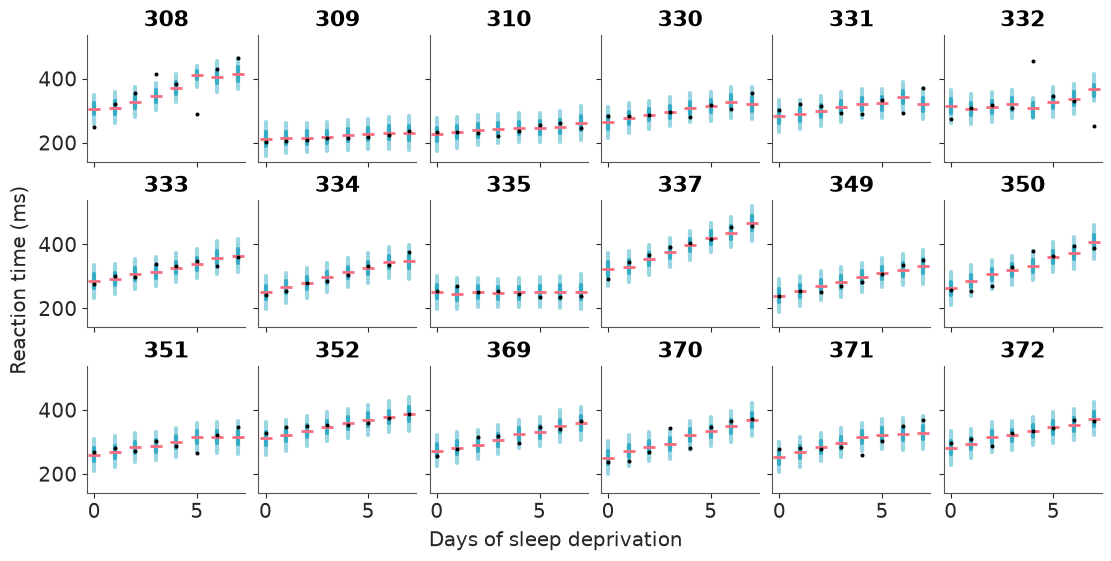

In [10]:
plot_loo_participants(idatas["gaussian_slope"])
plt.show()

### 2.4 Which observations does the Gaussian model find hardest to predict?

Look for observations far outside their 90% intervals. Name the participant and the day, and say whether each is unusually slow or unusually fast for that participant.

Three observations lie far outside their 90% intervals. Participant 332 was unusually slow on day 4, about 454 ms where the model expected about 310 ms, and unusually fast on day 7, about 254 ms where it expected about 370 ms. Participant 308 was unusually fast on day 5, about 290 ms where the model expected about 410 ms. Each is a single unusual day, far from that participant's other observations, not a pattern that persists. A few other observations lie a little outside their intervals, such as participant 308's on days 0 and 3.

### 2.5 Plot the Student-t varying-slope model's leave-one-out predictions.

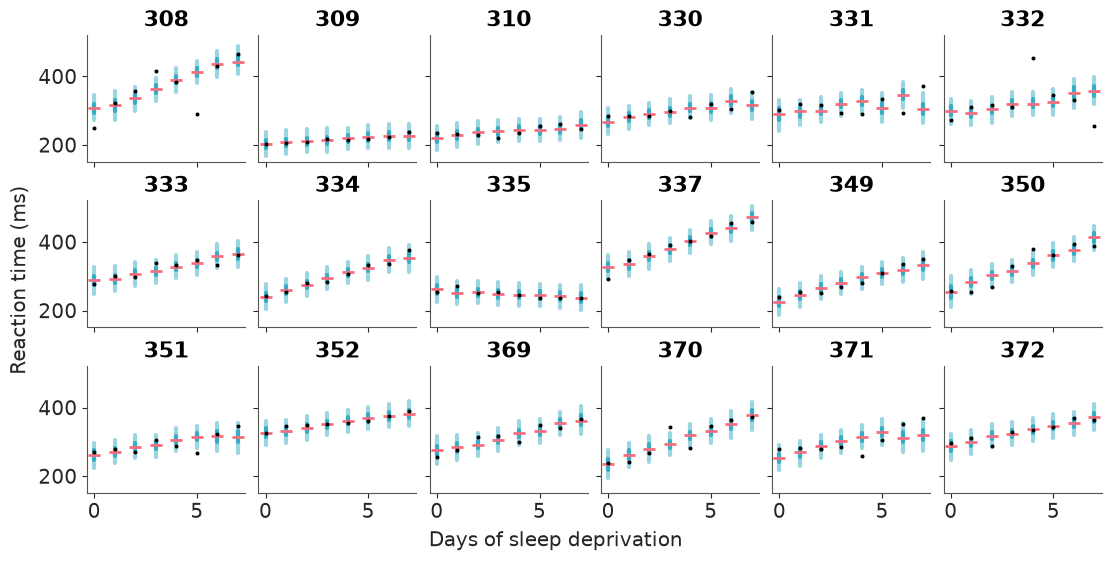

In [11]:
plot_loo_participants(idatas["student_t_slope"])
plt.show()

### 2.6 Does the Student-t likelihood change which observations are hard to predict?

Compare the two plots. Are the same observations far outside their intervals? How do the intervals of the other observations differ?

The same observations remain far outside their 90% intervals: participant 332's days 4 and 7 and participant 308's day 5. No likelihood can foresee an unusual day.

What changes is how the other observations are predicted. The Student-t model's intervals are narrower, the inner 50% intervals most of all, as for participants 309 and 335, whose observations lie close to their trajectories: it predicts the typical day more precisely. In the Gaussian model, the unusual days widen the intervals of every observation; the Student-t's heavy tails allow for such days without widening every interval.

## 3. Robust predictive calibration

### 3.1 What does a calibrated model's LOO-PIT look like?

For each observation, the **LOO-PIT** value is the probability, under its leave-one-out predictive distribution, of a reaction time at or below the observed one. An observation at the predictive median has a LOO-PIT of 0.5; one above everything the model predicted has a LOO-PIT near 1. If the predictive distributions are calibrated, the 144 LOO-PIT values are spread uniformly between 0 and 1: about 10% of them below 0.1, about half between 0.25 and 0.75, and so on.

`azp.plot_loo_pit` plots the empirical cumulative distribution function (ECDF) of the LOO-PIT values minus that of a uniform distribution, the **Δ-ECDF**, so a calibrated model stays close to the dashed zero line. The $p$ printed on the plot comes from a test of uniformity: a value below the stated α = 0.01 indicates miscalibration, and the highlighted points are the observations that contribute most to the departure.

The shape of the curve says how the predictions are miscalibrated. If the predictive distributions are too wide, too many LOO-PIT values fall in the middle, and the curve dips below zero before rising above it. If they are too narrow, too many fall near 0 and 1, and the curve rises above zero before dipping below it.

### 3.2 Plot the LOO-PIT of the two varying-slope models.

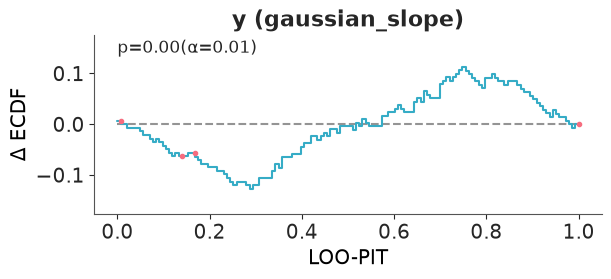

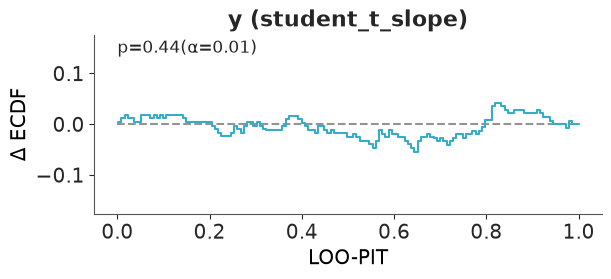

In [12]:
for name in ["gaussian_slope", "student_t_slope"]:
    azp.plot_loo_pit(idatas[name], var_names=["y"], visuals={"title": {"text": name}})
    plt.show()

### 3.3 Are the Gaussian model's leave-one-out predictions calibrated?

Use the $p$ value, the shape of the curve, and the highlighted points.

No. The test rejects uniformity ($p$ = 0.00, below α = 0.01). The curve dips below zero, to about −0.12 near a LOO-PIT of 0.3, and then rises above it, to about +0.11 near 0.75. Between LOO-PIT values of 0.25 and 0.75 it therefore climbs by about 0.23: about 50% + 23% = 73% of the observations fall in the middle half of their predictive distributions, instead of 50%, so those distributions are too wide for most observations. Points are highlighted at both ends, where the unusual days of Question 2.4 lie beyond almost everything the model predicted, and along the dip. The Gaussian model is too uncertain about the typical observation and too certain about the unusual ones.

### 3.4 Are the Student-t model's leave-one-out predictions calibrated?

Yes. The curve stays within about 0.05 of zero everywhere, the test does not reject uniformity ($p$ = 0.44), and no points are highlighted.

### 3.5 How does the Student-t likelihood predict both the typical and the unusual days better?

Compare `sd_y` in the two varying-slope models, and `nu` in the Student-t model, using the summaries in Question 1.7 and the prior in Question 1.3.

By combining a smaller scale with much heavier tails. In the Gaussian model, `sd_y` is about 26 ms: a single Gaussian must stretch to cover the unusual days, which makes every predictive distribution too wide. In the Student-t model, `sd_y` is about 12 ms, and `nu` is about 2.6 (90% HDI about 1.5–3.7), in the lower tail of its prior, which gave only 9% probability to values below 5. Most days lie close to the trajectory, and an occasional large deviation is expected rather than surprising. The data call for much heavier tails than a Gaussian's.

## 4. Predictive comparison

### 4.1 How does PSIS-LOO score a whole model?

Each observation's **log predictive density**, $\log p(y_i \mid y_{-i})$, measures how probable the model fitted without observation $i$ found the value actually observed; higher is better. Summed over all observations, it gives the model's **expected log pointwise predictive density (ELPD)**. An observation far outside its predictive distribution lowers the ELPD a lot, and a predictive distribution that is wider than necessary lowers it a little for every observation.

`azs.loo` returns the ELPD as `elpd`, with its standard error `se`; `p`, the effective number of parameters, which measures how much the model adapts to the data; and each observation's Pareto $k$ as `pareto_k`, together with `good_k`, the threshold below which $k$ is good. An ELPD means little on its own: it is compared between models fitted to the same observations.

### 4.2 Compute PSIS-LOO for each model.

Use `azs.loo` with `var_name="y"` and `pointwise=True`, and store the results in a dictionary `loos` with the model names as keys. Print each model's ELPD, its standard error, and its largest Pareto $k$.

In [13]:
loos = {
    name: azs.loo(idata, var_name="y", pointwise=True)
    for name, idata in idatas.items()
}

for name, loo in loos.items():
    print(
        f"{name}: ELPD {loo.elpd:.1f}, SE {loo.se:.1f}, "
        f"largest Pareto k {loo.pareto_k.max().item():.2f}"
    )

/tmp/claude-0/-home-user-BayesShortCourse/454cacc3-077e-57ca-973e-ce021f0d1966/scratchpad/nbenv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


gaussian_intercept: ELPD -706.7, SE 14.6, largest Pareto k 0.64
gaussian_slope: ELPD -690.7, SE 21.7, largest Pareto k 0.97
student_t_intercept: ELPD -698.5, SE 12.2, largest Pareto k 0.54
student_t_slope: ELPD -652.7, SE 14.1, largest Pareto k 0.49


### 4.3 How should Pareto $k$ be read?

Each observation's Pareto $k$ estimates how heavy the tail of its importance weights is, which grows with how far the posterior without that observation lies from the full posterior. Below 0.7, `good_k` here, the observation's PSIS-LOO estimate is reliable. Above it, the estimate is unreliable, and it tends to be too favorable to the model, because the full posterior has been pulled toward the very observation it is supposed to predict without.

A high $k$ does not mean that sampling failed, or that the observation is an error. It means that the observation is **influential**: the fit changes noticeably without it. It should be diagnosed, not deleted. The exact leave-one-out value of a flagged observation can be obtained by refitting the model without it, and a model that is less sensitive to single observations may not produce high $k$ values at all. Finally, $k$ is itself estimated from the posterior draws, so a value near 0.7 can fall on the other side of the threshold in another run.

### 4.4 Plot the Pareto $k$ values of the two varying-slope models, and list the flagged observations.

In each plot, the horizontal line marks 0.7, and the percentages give the share of observations on either side of it. The horizontal axis numbers the observations in the order of the data, so the table below the plots lists, with its participant and day, every observation whose $k$ exceeds 0.7 in any of the four models.

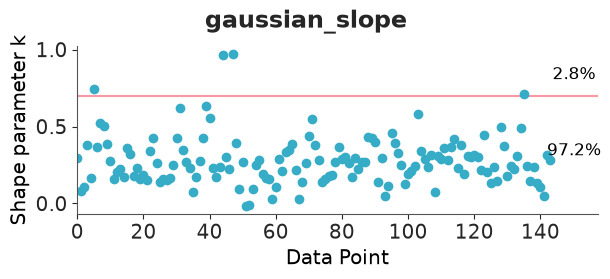

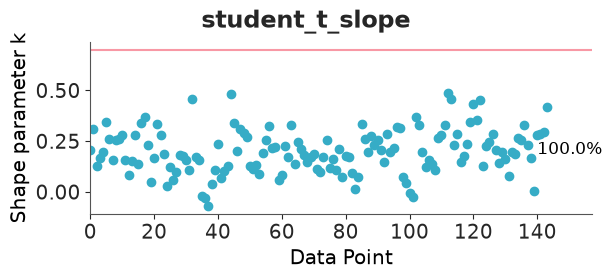

,Subject,Days,Reaction,gaussian_intercept,gaussian_slope,student_t_intercept,student_t_slope
5,308,5,290.15,0.55,0.75,0.46,0.35
44,332,4,454.16,0.64,0.97,0.54,0.48
47,332,7,253.86,0.58,0.97,0.41,0.31
135,371,7,369.47,0.12,0.71,0.27,0.26


In [14]:
for name in ["gaussian_slope", "student_t_slope"]:
    pc = azp.plot_khat(loos[name], hline_values=[0.7], visuals={"hlines": {}, "bin_text": {}})
    pc.get_viz("figure").suptitle(name)
    plt.show()

pareto_k = pd.DataFrame({name: loo.pareto_k.values for name, loo in loos.items()})
flagged = (pareto_k > 0.7).any(axis="columns")
sleep[["Subject", "Days", "Reaction"]].join(pareto_k)[flagged].round(2)

### 4.5 Which models have unreliable PSIS-LOO estimates, and for which observations?

Use the printed largest $k$ values, the plots, and the table, and compare the flagged observations with those of Question 2.4. Why might an unusual day be influential under one likelihood but not under the other? In test runs of this notebook with other random seeds, the largest $k$ of `gaussian_slope` ranged from about 0.8 to 1.3, and that of `gaussian_intercept` from about 0.65 to 0.8.

Only `gaussian_slope` has observations with $k$ above 0.7, four of them (2.8%): participant 332's days 4 and 7, with $k$ about 0.97, participant 308's day 5, about 0.75, and, just above the threshold, participant 371's day 7. The first three are the hard-to-predict days of Question 2.4. The largest $k$ of `gaussian_intercept`, about 0.64, for participant 332's day 4, is below the threshold, but since it crossed 0.7 in some test runs, it is borderline. Both Student-t models stay below about 0.55 for every observation.

Under a Gaussian likelihood, an unusual day pulls the participant's trajectory and `sd_y` toward itself, so leaving it out changes the posterior noticeably. The Student-t likelihood treats such a day as a draw from its heavy tails, so leaving it out changes little.

### 4.6 What does a model comparison table show, and what does it not?

`azs.compare` ranks the models by ELPD and reports, for each model:

- `elpd_diff`: its ELPD minus that of the best model, which therefore has 0;
- `dse`: the standard error of that difference. It is computed observation by observation, pairing the two models' predictions of the same observation, so it is usually much smaller than the models' separate `se` values suggest;
- `p_worse`: the probability that the model predicts worse than the best one, from a normal approximation;
- `diag_diff`: a warning when the difference is too small, or the data too few, for that normal approximation to be trusted;
- `diag_elpd`: the number of observations with $k$ above the threshold, whose unreliable estimates can bias the comparison in the model's favor;
- `weight`: the **stacking** weights, the weights of the mixture of the models' predictive distributions that would have predicted the left-out observations best.

`azp.plot_compare` draws each model's `elpd_diff` as a point, with a bar extending one `dse` to either side.

Stacking weights are not probabilities that the models are true: a model can get weight 0 because another model makes the same predictions better, and similar weights do not mean that models are equivalent. A rank is not proof either: judge each ELPD difference against its `dse`, and remember that the comparison is about predictions, not about which model is scientifically true.

### 4.7 Compare the four models.

Use `azs.compare` on `loos` with `round_to=2`, store the table as `comparison`, and plot it with `azp.plot_compare`.

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
student_t_slope,0,0.00,0.00,NaN,,,43.69,-652.67,14.09,1.0
gaussian_slope,1,-38.02,12.85,1.0,,4 k̂ > 0.70,31.28,-690.69,21.72,0.0
student_t_intercept,2,-45.81,8.71,1.0,,,23.61,-698.48,12.22,0.0
gaussian_intercept,3,-54.02,9.57,1.0,,,19.20,-706.69,14.58,0.0


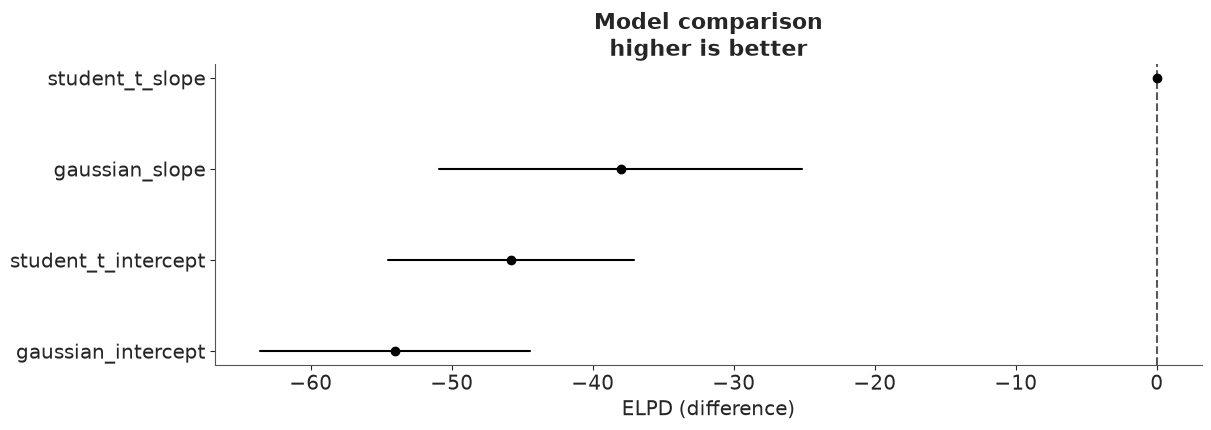

In [15]:
comparison = azs.compare(loos, round_to=2)
display(comparison)
azp.plot_compare(comparison);

### 4.8 Which model predicts best, and does the high Pareto $k$ of `gaussian_slope` put that in doubt?

In test runs, refitting `gaussian_slope` without each of the observations it flags, which gives their exact leave-one-out values, lowered its ELPD by less than 2 in total.

`student_t_slope`, clearly. The next best, `gaussian_slope`, has an ELPD about 38 lower, with a `dse` of about 13: the difference is about three standard errors, and `p_worse` is essentially 1. All the stacking weight goes to `student_t_slope`.

The high $k$ values make four of `gaussian_slope`'s 144 pointwise estimates unreliable, which `diag_elpd` flags. They do not put the ranking in doubt. Such estimates tend to be too favorable, so exact values widen the gap rather than close it, as the test refits confirm; and to close a gap of 38, four estimates would have to be wrong by about 10 each.

### 4.9 Compare every model with the simplest one.

`azs.compare` measures every difference from the best model unless a `reference` model is given. Repeat the comparison with `reference="gaussian_intercept"`. The column `p_worse` then becomes `p_better`, the probability that each model predicts better than the reference.

In [16]:
azs.compare(loos, reference="gaussian_intercept", round_to=2)

,rank,elpd_diff,dse,p_better,diag_diff,diag_elpd,p,elpd,se,weight
student_t_slope,0,54.02,9.57,1.00,,,43.69,-652.67,14.09,1.0
gaussian_slope,1,16.00,9.71,0.95,,4 k̂ > 0.70,31.28,-690.69,21.72,0.0
student_t_intercept,2,8.22,5.34,0.94,,,23.61,-698.48,12.22,0.0
gaussian_intercept,3,0.00,0.00,NaN,,,19.20,-706.69,14.58,0.0


### 4.10 How much does each change improve prediction, with and without the other?

Between them, the tables in Questions 4.7 and 4.9 contain all four comparisons in which only one thing changes: the likelihood, with a shared slope and with varying slopes, and the mean structure, with each likelihood. Quote each ELPD difference with its `dse`.

Each change improves prediction in both settings, but by very different amounts:

| Change | With the other change absent | With the other change present |
|---|---|---|
| Gaussian → Student-t | about 8 (`dse` about 5), shared slope | about 38 (about 13), varying slopes |
| shared → varying slopes | about 16 (about 10), Gaussian | about 46 (about 9), Student-t |

On its own, each change gives a modest improvement of less than two standard errors, with `p_better` about 0.95. Together, they improve the ELPD by about 54, far more than 8 + 16. The two comparisons that involve `gaussian_slope` carry its slightly too favorable estimate (Question 4.8), which does not change this picture.

### 4.11 Why does each change help more when the other is present?

Compare `nu` in the two Student-t models (summaries in Question 1.7). What kind of deviation from the trajectory remains when all participants share one slope, and what kind remains when slopes vary?

Because each change fixes a problem that the other exposes. With a shared slope, a participant whose own slope differs from it deviates from the trajectory on many days in a row, in the same direction. Heavy tails cannot describe such a systematic mismatch, and the shared-slope Student-t model estimates only moderately heavy tails (`nu` about 6, 90% HDI about 2–10). Once slopes vary, what remains is small day-to-day scatter plus a few unusual days: exactly the pattern a Student-t describes, and its `nu` drops to about 2.6.

Conversely, under a Gaussian likelihood the unusual days widen the predictive distribution of every observation, so the more accurate trajectories of the varying-slope model improve the predictions less than they could.

## 5. What the comparison answers

### 5.1 What prediction task does this comparison evaluate?

Leave-one-out cross-validation left out one row of the data at a time. What remains known about that observation's participant? Does the comparison tell us how well the models would predict a new participant, or a participant's future reaction times?

Predicting another observation of a participant who is already in the data. Leaving out one row keeps that participant's other seven observations, so their own intercept and slope are still estimated; the task resembles filling in a missed session.

It does not tell us how well the models predict a new participant. That would require leaving out all eight of a participant's observations at once, so that the prediction must come from the population distribution of intercepts and slopes; leaving out a whole participant changes the posterior too much for PSIS, so it would require refitting. Nor is it forecasting: leaving out day 4 while keeping days 5–7 asks the model to interpolate, not to predict the future.

### 5.2 Does the choice of model change the conclusion about sleep deprivation?

Compare the posterior for the population-average daily effect across the four models, using the summaries in Question 1.7. It is `b1` in the shared-slope models and `mu_b1` in the varying-slope models (Question 1.5).

No. The same quantity has two names because it plays two roles: in the shared-slope models, `b1` is every participant's slope, and in the varying-slope models, `mu_b1` is the center of the distribution of participants' slopes. In all four models its posterior mean is about 11.3–11.6 ms/day. The likelihood hardly changes it. The mean structure changes its uncertainty: the 90% HDI is about 9.6–13.2 ms/day for `b1` in `gaussian_intercept` but about 8.1–14.6 ms/day for `mu_b1` in `gaussian_slope`, and similarly for the two Student-t models. A shared-slope model assumes that every participant has the same slope, although participants' slopes clearly differ (`sd_b1` about 7–8 ms/day), so it is overconfident about the average.

The comparison chooses between models for predicting observations. It leaves the scientific conclusion unchanged: on average, reaction time slows by about 11 ms per day of sleep deprivation.

### 5.3 What has this notebook shown?

Summarize what the four-way comparison showed, what the Pareto $k$ diagnostics flagged, and what the comparison does and does not establish.

- **Four models.** Notebook 4's and Notebook 5's models, each with a Gaussian and a Student-t likelihood, share the priors of those notebooks; the Student-t models add one for the degrees of freedom $\nu$, Bambi's default $\operatorname{Gamma}(2, 0.1)$. With the centered parameterization, all four sampled cleanly with default settings.
- **Hard-to-predict observations.** A few unusual days, participant 332's days 4 and 7 and participant 308's day 5, lie far outside their leave-one-out intervals under either likelihood. The Student-t likelihood predicts the other days with narrower intervals.
- **Calibration.** The Gaussian varying-slope model's leave-one-out predictions are miscalibrated: too wide for most observations and too narrow for the unusual ones. The Student-t model's are calibrated, with a smaller scale and heavy tails ($\nu$ about 2.6).
- **Pareto $k$.** Only the Gaussian varying-slope model had unreliable PSIS-LOO estimates, for four influential observations, three of them the unusual days; the shared-slope Gaussian model was borderline. Under a Student-t likelihood, no observation was influential enough to be flagged. The flags did not change the ranking.
- **Comparison.** `student_t_slope` predicts best, about 38 (`dse` about 13) above `gaussian_slope`. Each change helps most in the presence of the other: the Student-t likelihood adds little while unmodeled slope differences dominate the residuals, and varying slopes add less while a Gaussian likelihood lets unusual days widen every prediction.
- **What it does not establish.** The comparison scores predictions of new observations of already-observed participants, not of new participants or of future days. A rank or a stacking weight is not proof that a model is true, and the population-average effect of sleep deprivation, about 11 ms/day, is the same in all four models.

This notebook ends the sleep-deprivation sequence. To the posterior predictive checks used throughout, it added a check of how well each fitted model predicts observations it was not fitted to.